In [2]:
# EXploratory Data Analysys

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [4]:
import pandas as pd

df = pd.read_pickle("G:/Mohanraj D_OFFICIAL/GUVI (Data Analyst)/Mini-Projects/PatrolIQ/cleaned_chicago_crime_dataset.pkl")
df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,10819224,JA119772,2016-12-31 23:59:00,100XX W OHARE ST,0810,THEFT,OVER $500,AIRPORT BUILDING NON-TERMINAL - SECURE AREA,False,False,...,41,76,06,1100658.0,1934241.0,2016,2018-02-10 15:50:01,41.976290,-87.905227,"(41.976290414, -87.905227221)"
1,10801137,JA100016,2016-12-31 23:58:00,0000X W 113TH PL,0430,BATTERY,AGGRAVATED: OTHER DANG WEAPON,RESIDENCE,False,False,...,34,49,04B,1178014.0,1829709.0,2016,2018-02-10 15:50:01,41.688033,-87.623931,"(41.688033246, -87.623931468)"
2,10801110,JA100027,2016-12-31 23:55:00,030XX N LINCOLN AVE,2250,LIQUOR LAW VIOLATION,LIQUOR LICENSE VIOLATION,RESIDENCE,True,False,...,32,6,22,1166154.0,1920300.0,2016,2017-01-07 15:56:13,41.936885,-87.664770,"(41.936884881, -87.66476981)"
3,10802006,JA100012,2016-12-31 23:55:00,0000X E WACKER PL,0486,BATTERY,DOMESTIC BATTERY SIMPLE,HOTEL/MOTEL,False,True,...,42,32,08B,1176964.0,1902140.0,2016,2018-02-10 15:50:01,41.886815,-87.625593,"(41.886814897, -87.625592678)"
4,10801865,JA100839,2016-12-31 23:54:00,078XX S INDIANA AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,True,...,6,69,14,1178949.0,1853139.0,2016,2018-02-10 15:50:01,41.752307,-87.619798,"(41.752307019, -87.619797619)"


In [6]:
df.dtypes

ID                               Int64
Case Number                     object
Date                    datetime64[ns]
Block                         category
IUCR                          category
Primary Type                  category
Description                   category
Location Description          category
Arrest                            bool
Domestic                          bool
Beat                             int64
District                         Int64
Ward                             Int64
Community Area                   Int64
FBI Code                      category
X Coordinate                   float64
Y Coordinate                   float64
Year                             int64
Updated On              datetime64[ns]
Latitude                       float64
Longitude                      float64
Location                        object
dtype: object

In [7]:
df.describe()

,ID,Date,Beat,District,Ward,Community Area,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude
count,2965087.0,2965087,2.965087e+06,2965087.0,2965087.0,2965087.0,2.965087e+06,2.965087e+06,2.965087e+06,2965087,2.965087e+06,2.965087e+06
mean,8372967.57623,2012-02-01 16:32:46.317020416,1.179094e+03,11.31052,22.768564,37.719839,1.164389e+06,1.885367e+06,2.011584e+03,2018-03-27 08:06:45.961063936,4.184105e+01,-8.767228e+01
min,4381.0,2008-01-01 00:00:00,1.110000e+02,1.0,1.0,0.0,0.000000e+00,0.000000e+00,2.008000e+03,2015-08-17 15:03:40,3.661945e+01,-9.168657e+01
25%,7201759.5,2009-10-27 02:30:00,6.210000e+02,6.0,10.0,23.0,1.152624e+06,1.858657e+06,2.009000e+03,2018-02-10 15:50:01,4.176751e+01,-8.771501e+01
50%,8359031.0,2011-11-12 19:00:00,1.032000e+03,10.0,22.0,32.0,1.165897e+06,1.890453e+06,2.011000e+03,2018-02-10 15:50:01,4.185500e+01,-8.766656e+01
75%,9555604.5,2014-03-27 15:30:00,1.723000e+03,17.0,34.0,58.0,1.176352e+06,1.909112e+06,2.014000e+03,2018-02-28 15:56:25,4.190647e+01,-8.762841e+01
max,14035976.0,2016-12-31 23:59:00,2.535000e+03,31.0,50.0,77.0,1.205119e+06,1.951573e+06,2.016000e+03,2026-05-14 15:41:50,4.202271e+01,-8.752453e+01
std,1408822.206188,NaN,6.998038e+02,6.9289,13.763055,21.54759,1.777619e+04,3.341454e+04,2.563467e+00,NaN,9.197357e-02,6.418248e-02


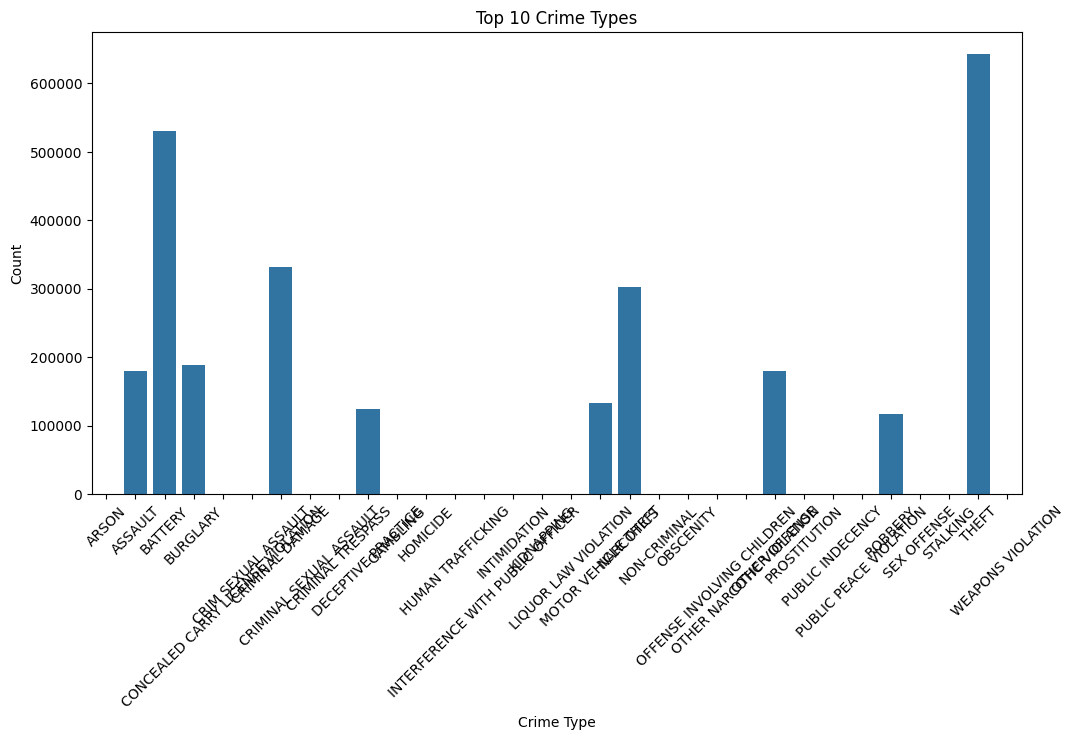

In [8]:
# Top 10 Crime Types

top_crimes = df['Primary Type'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_crimes.index, y=top_crimes.values)

plt.title("Top 10 Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

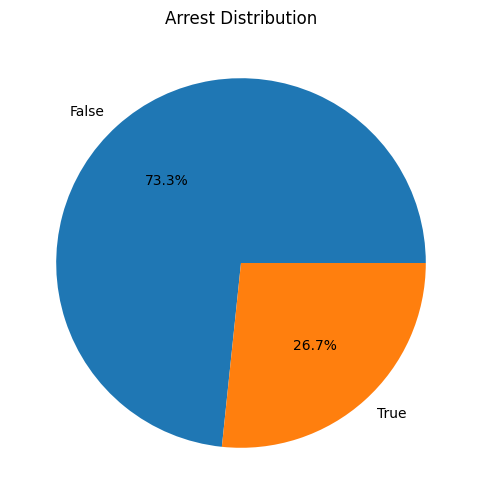

In [9]:
# Arrest vs Non-Arrest

df['Arrest'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Arrest Distribution")
plt.ylabel("")

plt.show()

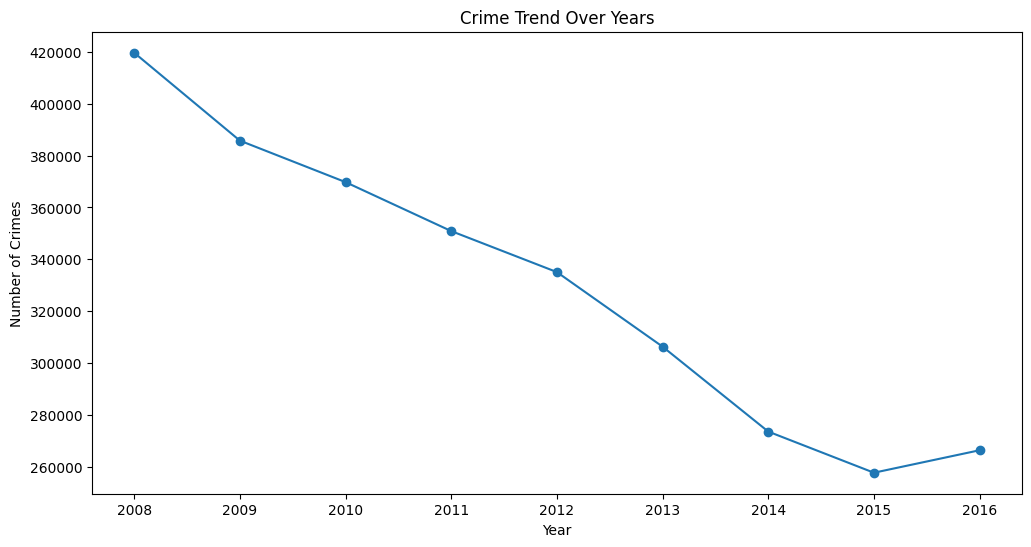

In [10]:
# Crimes by Year

crime_year = df.groupby('Year').size()

plt.figure(figsize=(12,6))
crime_year.plot(marker='o')

plt.title("Crime Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")

plt.show()

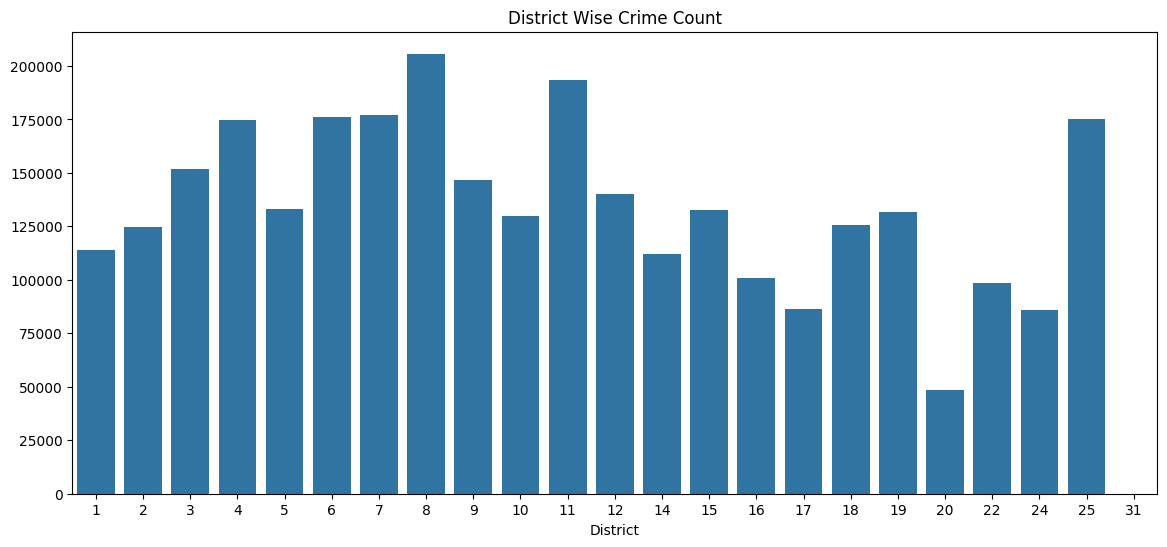

In [13]:
# District Wise Crime Count

district_crime = df['District'].value_counts().sort_index()

plt.figure(figsize=(14,6))

sns.barplot(
    x=district_crime.index,
    y=district_crime.values
)

plt.title("District Wise Crime Count")

plt.show()

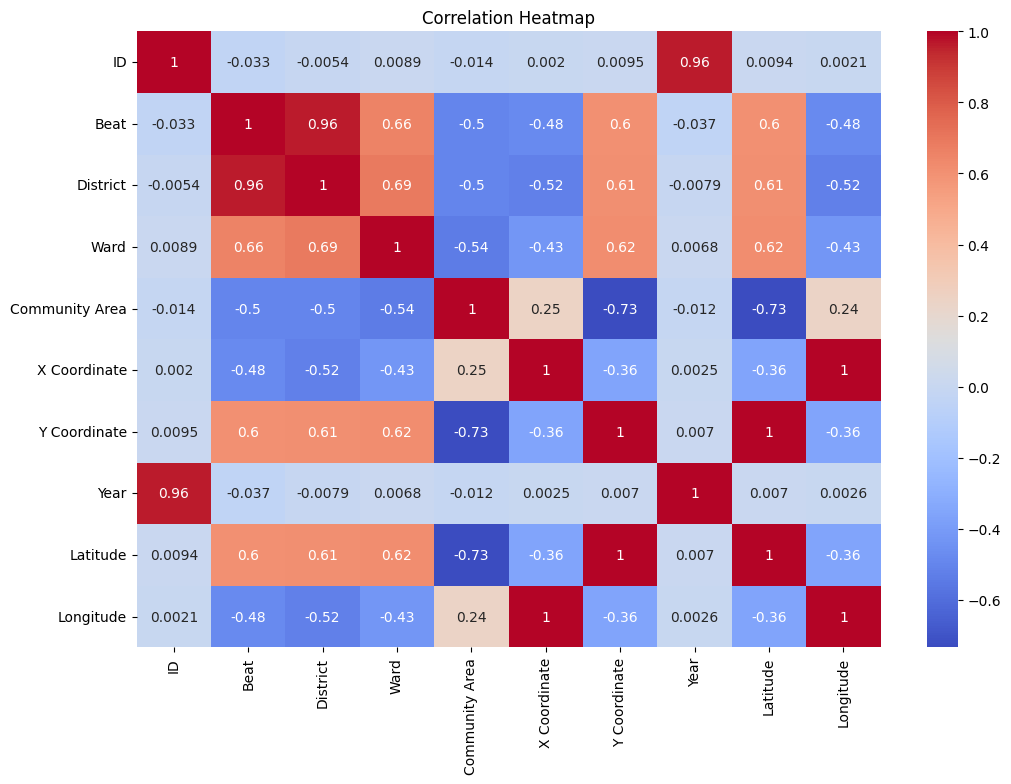

In [14]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

num_cols = df.select_dtypes(include=['int64','float64'])

sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

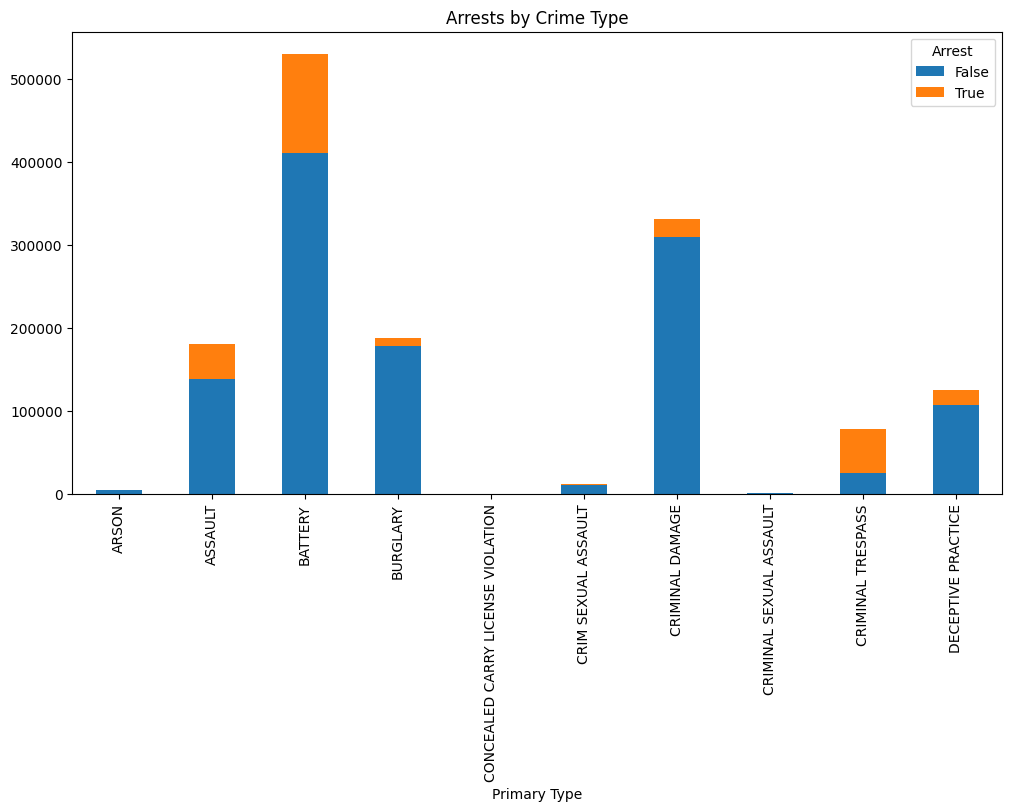

In [15]:
# Arrests by Crime Type

arrest_crime = pd.crosstab(
    df['Primary Type'],
    df['Arrest']
).head(10)

arrest_crime.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Arrests by Crime Type")

plt.show()

<Axes: xlabel='Longitude', ylabel='Latitude'>

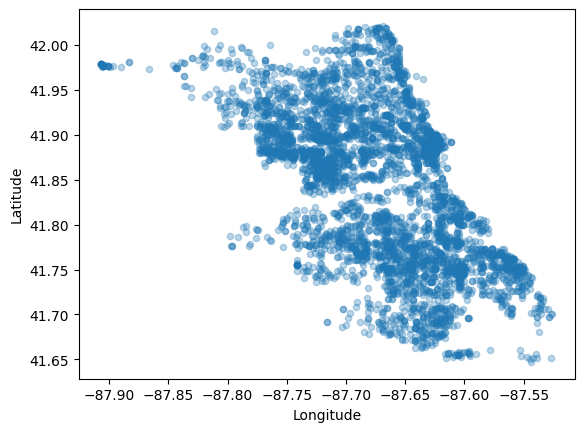

In [16]:
# recent five thousand crime locations 
df.head(5000).plot(kind="scatter", x="Longitude", y="Latitude", alpha=0.3)

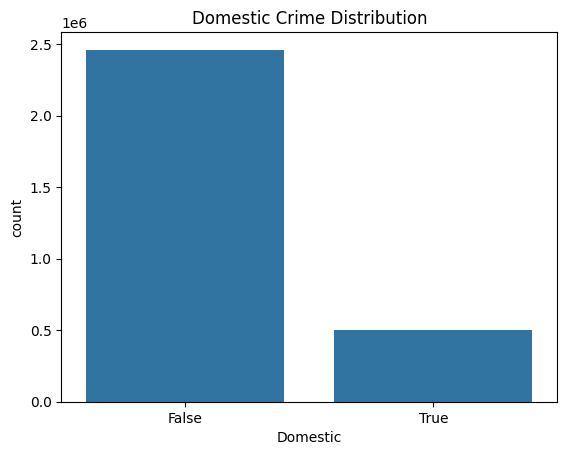

In [17]:
# Domestic Crimes

sns.countplot(x='Domestic', data=df)

plt.title("Domestic Crime Distribution")

plt.show()

In [18]:
pd.crosstab(df["Primary Type"], df["Domestic"])

Domestic,False,True
Primary Type,,
ARSON,4255,219
ASSAULT,127536,52654
BATTERY,241604,288818
BURGLARY,186391,1678
CONCEALED CARRY LICENSE VIOLATION,84,0
CRIM SEXUAL ASSAULT,9208,2446
CRIMINAL DAMAGE,294483,36775
CRIMINAL SEXUAL ASSAULT,433,102
CRIMINAL TRESPASS,73849,3719


In [19]:
df.describe(include='category')

,Block,IUCR,Primary Type,Description,Location Description,FBI Code
count,2965087,2965087,2965087,2965087,2965087,2965087
unique,33643,375,32,407,182,26
top,001XX N STATE ST,0486,THEFT,SIMPLE,STREET,06
freq,5728,259258,642692,303266,712981,642692
